## Automated Recognition and Evaluation of Mathematical Expressions
* Addition, Subtraction, Multiplication, Division

### Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data.dataloader import DataLoader
from tqdm.auto import trange,tqdm
from torchsummary import summary
from torchvision.datasets import ImageFolder

### Data Loading : Digits

In [2]:
train_data = torchvision.datasets.MNIST(
    root='Data',
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True,
    target_transform=None
)

test_data =  torchvision.datasets.MNIST(
    root='Data',
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

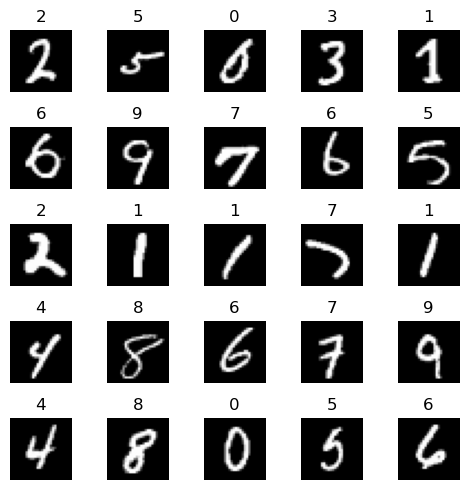

In [3]:
figure = plt.figure(figsize=(5, 5))
cols, rows = 5, 5

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

plt.tight_layout()
plt.show()

### Data Loading Batches : Digits

In [4]:
batch = 32
train_data_loader = DataLoader(train_data,batch_size=32,shuffle=True)

test_data_loader = DataLoader(test_data,batch_size=32,shuffle=False)

class_names = train_data.classes
len(train_data_loader),len(test_data_loader),class_names
print(f'Number of batches in Train data : {len(train_data_loader)}, with batch size : {batch}')
print(f'Number of batches in Test data : {len(test_data_loader)}, with batch size : {batch}')

Number of batches in Train data : 1875, with batch size : 32
Number of batches in Test data : 313, with batch size : 32


### Visualizing a Single Image : Digit

(torch.Size([1, 28, 28]), 4)

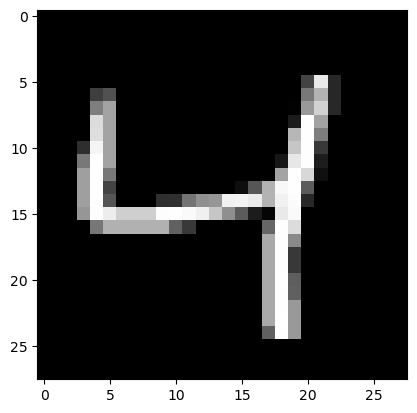

In [5]:
img,label = train_data[2]
plt.imshow(img.squeeze(dim=0),cmap='gray')
img.shape,label

### Building a Model for Digits : CNN
* 6 - Convolution Layers ( 32, 64, 128 ), 6 - Activation Functions, 2 - MaxPool layers, 2 - Fully Connected Dense Layers , 1-  Dropout layer
* We can compute the Flattened Size automatically : No-grad and dummy input

In [6]:
class CNN_DIGITS(nn.Module):
    def __init__(self,input , output):
        super().__init__()

        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=input,out_channels=32,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

        )

        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128,out_channels=128,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=128,out_channels=128,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128,out_channels=128,kernel_size=3,padding=1,stride=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128 * 7 * 7,out_features=output)
        )

    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.classifier(x)
        return x
    
Digits_Model = CNN_DIGITS(1,10)

summary(Digits_Model,input_size=(1,28,28),device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 64, 28, 28]          18,496
              ReLU-4           [-1, 64, 28, 28]               0
         MaxPool2d-5           [-1, 64, 14, 14]               0
            Conv2d-6          [-1, 128, 14, 14]          73,856
              ReLU-7          [-1, 128, 14, 14]               0
            Conv2d-8          [-1, 128, 14, 14]         147,584
              ReLU-9          [-1, 128, 14, 14]               0
        MaxPool2d-10            [-1, 128, 7, 7]               0
           Conv2d-11            [-1, 128, 7, 7]         147,584
             ReLU-12            [-1, 128, 7, 7]               0
           Conv2d-13            [-1, 128, 7, 7]         147,584
             ReLU-14            [-1, 12

### Loss Function and Optimizer

In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=Digits_Model.parameters(),lr=0.06)

### Function for Training

In [8]:

def train_step(Model:torch.nn.Module,data_loader:nn.Module,loss_fn,optimizer,device):

    Model.train()
    Model.to(device)
    train_loss,train_acc = 0,0
    total_correct,total_samples = 0,0

    for X,y in data_loader:
        X,y = X.to(device),y.to(device)

        pred = Model(X)
        
        pred_label = pred.argmax(dim=1)
        loss = loss_fn(pred,y)
        train_loss = train_loss + loss.item() * y.size(0)
        
        total_correct = total_correct + (pred_label == y).sum().item()
        total_samples = total_samples + y.size(0)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    train_loss = train_loss / total_samples
    train_acc = 100 * total_correct / total_samples

    print(f'Train Loss : {train_loss:.5f}, Train Acc : {train_acc:.2f}, Total Samples : {total_samples}')


### Function for Testing

In [9]:
def test_step(Model:torch.nn.Module,data_loader,loss_fn,device):

    Model.to(device)
    Model.eval()
    test_loss,test_acc = 0,0
    total_correct,total_samples = 0,0
    with torch.inference_mode():
        for X,y in data_loader:
            X,y = X.to(device),y.to(device)

            pred = Model(X)

            loss = loss_fn(pred,y)
            pred_label = pred.argmax(dim=1)
            test_loss = test_loss + loss.item() * y.size(0)
            total_correct = total_correct + (pred_label == y).sum().item()
            total_samples = total_samples + y.size(0)

        test_loss = test_loss / total_samples
        test_acc = 100 * total_correct / total_samples

        print(f'Test Loss : {test_loss:.5f}, Test Acc : {test_acc:.2f}, Total Samples : {total_samples}')

### Training and Testing The Digits Model

In [10]:
torch.manual_seed(42)

epochs = 3


for epoch in trange(epochs):
    print(f'Epoch : {epoch+1}\n')

    
    train_step(Digits_Model,train_data_loader,loss_fn,optimizer,device='cuda')
    test_step(Digits_Model,test_data_loader,loss_fn,device = 'cuda')

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 1

Train Loss : 0.39723, Train Acc : 86.13, Total Samples : 60000
Test Loss : 0.06228, Test Acc : 98.06, Total Samples : 10000
Epoch : 2

Train Loss : 0.05836, Train Acc : 98.14, Total Samples : 60000
Test Loss : 0.05119, Test Acc : 98.32, Total Samples : 10000
Epoch : 3

Train Loss : 0.03822, Train Acc : 98.80, Total Samples : 60000
Test Loss : 0.03872, Test Acc : 98.65, Total Samples : 10000


### Transforms for Custom Image

In [11]:
digit_transform = transforms.Compose([
    transforms.Lambda(lambda x: x[:3, :, :] if x.shape[0] == 4 else x),
    transforms.Resize((28,28),antialias=True),
    transforms.Grayscale(num_output_channels=1),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Lambda(lambda x:1.0 - x)
    # transforms.ToTensor()
])

In [12]:
class_names_digit = {'0 - zero':0,
 '1 - one':1,
 '2 - two':2,
 '3 - three':3,
 '4 - four':4,
 '5 - five':5,
 '6 - six':6,
 '7 - seven':7,
 '8 - eight':8,
 '9 - nine':9}

### Prediction for a Single Custom Image : Digit

Predicted Digit : tensor([5], device='cuda:0')


5

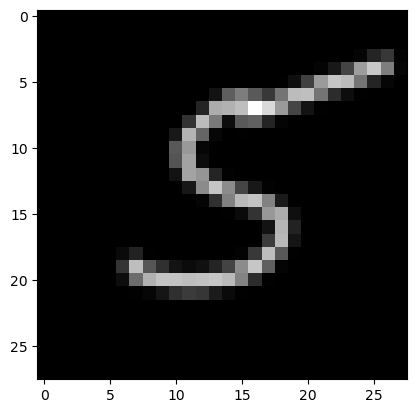

In [13]:
from torchvision.io import read_image 
def Predict_Digit(image_path,Model,transformer,device,show):
    
    Model.to(device)
    image = read_image(image_path) # returning Tensors
    
    if transformer:
        image = transformer(image)
    image = image.to(device)
    
    image = image.to(torch.float32) 
    image = image.unsqueeze(dim=0)
    Model.eval()
    with torch.inference_mode():

        pred = Model(image)

    pred_prob = torch.softmax(pred,dim=1)
    pred_label = torch.argmax(pred_prob,dim=1)
    
    if show == True:
        plt.imshow(image.squeeze().cpu(),cmap='gray')
    digit = class_names[pred_label]
    return pred_label


# Custom Image
image_path = r"C:\Users\abaan\OneDrive\Desktop\PROGRAMMING\DATA_SCIENCE\Deep_Learning\NIT_Project_DL\Test\five_1.png"
Digit = Predict_Digit(image_path,transformer=digit_transform,Model=Digits_Model,device='cuda',show=True)
print(f'Predicted Digit : {Digit}')
int(Digit)

### Data Loading : Operators

In [14]:
from torchvision.transforms import ToPILImage

data_path = Path('Data/')
# operators_path = data_path / r'/MNIST/raw/operators'
operators_path = r"C:\Users\abaan\OneDrive\Desktop\PROGRAMMING\DATA_SCIENCE\Deep_Learning\NIT_Project_DL\operators"

# operators_path `
print(operators_path)
import os
print(os.path.exists(operators_path))


transformer = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.Grayscale(1),
    transforms.ToTensor()
])

# Removing extra dimension in an image
def remove_alpha_channel(x):
    return x[:3, :, :] if x.shape[0] == 4 else x

# Inverting an image for MNIST
def invert_image(x):
    return 1.0 - x

from torchvision.transforms import functional as F

# Class for Operator Transformation
class FastOperatorTransform:

    def __init__(self):
        pass

    def __call__(self, image):

        if isinstance(image,torch.Tensor):
            image = ToPILImage()(image)
            
        image = F.resize(image,size=(28,28),antialias=True)
        image = F.to_grayscale(image,1)
        image = F.to_tensor(image)
        image = 1.0 - image
        return image
    
custom_transform_op = FastOperatorTransform()

dataset_operators = ImageFolder(root=operators_path,transform=custom_transform_op)

total_size = len(dataset_operators)
train_size = int(0.9 * total_size)
test_size = total_size - train_size

print(f'Total Size : {total_size}\nTrain Size : {train_size}\nTest Size : {test_size}')
dataset_operators

C:\Users\abaan\OneDrive\Desktop\PROGRAMMING\DATA_SCIENCE\Deep_Learning\NIT_Project_DL\operators
True
Total Size : 70177
Train Size : 63159
Test Size : 7018


Dataset ImageFolder
    Number of datapoints: 70177
    Root location: C:\Users\abaan\OneDrive\Desktop\PROGRAMMING\DATA_SCIENCE\Deep_Learning\NIT_Project_DL\operators
    StandardTransform
Transform: <__main__.FastOperatorTransform object at 0x0000025D8DC89010>

### Splitting and Loading The Operators Dataset

In [15]:
train_data_op, test_data_op = torch.utils.data.random_split(dataset_operators,[train_size,test_size])
BATCH = 128
NUM_WORKERS = 0
train_data_op_loader = DataLoader(train_data_op,batch_size=BATCH,num_workers=NUM_WORKERS,shuffle=True,pin_memory=True)
test_data_op_loader = DataLoader(test_data_op,batch_size=BATCH,num_workers=NUM_WORKERS,shuffle=False,pin_memory=True)

print(f'Number of batches in Train data : {len(train_data_op_loader)}, with batch size : {BATCH}')
print(f'Number of batches in Test data : {len(test_data_op_loader)}, with batch size : {BATCH}')

Number of batches in Train data : 494, with batch size : 128
Number of batches in Test data : 55, with batch size : 128


### Visualizing a Single Operator Image

(['add', 'div', 'mul', 'subtract'], 1, torch.Size([1, 28, 28]))

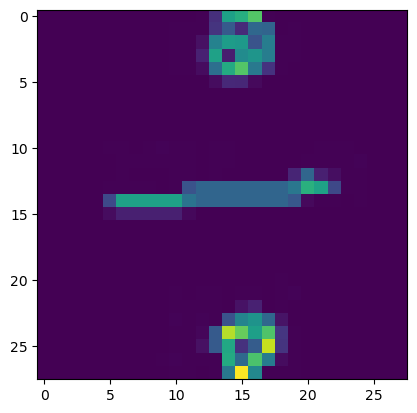

In [16]:
torch.manual_seed(42)
img,label = train_data_op[0]
plt.imshow(img.squeeze(1).permute(1,2,0))
class_names_op = dataset_operators.classes
class_names_op,label,img.shape

### Building a Model for Operators : CNN

In [17]:
class CNN_OPERATORS(nn.Module):
    def __init__(self, input, output):
        super().__init__()

        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=input,out_channels=32,kernel_size=3,padding=1,stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=64,out_channels=64,kernel_size=3,padding=1,stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64,out_channels=64,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128,out_channels=128,kernel_size=3,padding=1,stride=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7,out_features=output)
        )

    def forward(self,x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.classifier(x)
        return x
    
Operators_Model = CNN_OPERATORS(1,4)
Operators_Model

CNN_OPERATORS(
  (conv_layer_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): 

In [18]:
summary(Operators_Model,input_size=(1,28,28),device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
            Conv2d-4           [-1, 64, 28, 28]          18,496
              ReLU-5           [-1, 64, 28, 28]               0
         MaxPool2d-6           [-1, 64, 14, 14]               0
            Conv2d-7           [-1, 64, 14, 14]          36,928
       BatchNorm2d-8           [-1, 64, 14, 14]             128
              ReLU-9           [-1, 64, 14, 14]               0
           Conv2d-10           [-1, 64, 14, 14]          36,928
             ReLU-11           [-1, 64, 14, 14]               0
        MaxPool2d-12             [-1, 64, 7, 7]               0
           Conv2d-13            [-1, 128, 7, 7]          73,856
             ReLU-14            [-1, 12

### Loss Function and Optimizer

In [19]:
loss_fn_op = nn.CrossEntropyLoss()
optimizer_op = torch.optim.Adam(params=Operators_Model.parameters(),lr=0.001)

### Training and Evaluating The Model : Operators

In [20]:
from torchvision.transforms import functional as F


#---------------- For TESTING PURPOSE - WE CAN REMOVE IT------------------
# small_subset, _ = torch.utils.data.random_split(dataset_operators, [1000, len(dataset_operators)-1000])
# small_loader = DataLoader(small_subset, batch_size=64, shuffle=True)

torch.manual_seed(42)

epochs = 2
for epoch in trange(epochs):
    print(f'Epoch : {epoch+1}\n')
    train_step(Operators_Model,train_data_op_loader,loss_fn_op,optimizer_op,device='cuda')
    test_step(Operators_Model,test_data_op_loader,loss_fn_op,device='cuda')

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch : 1

Train Loss : 0.03489, Train Acc : 99.01, Total Samples : 63159
Test Loss : 0.01254, Test Acc : 99.79, Total Samples : 7018
Epoch : 2

Train Loss : 0.00594, Train Acc : 99.85, Total Samples : 63159
Test Loss : 0.01332, Test Acc : 99.76, Total Samples : 7018


### Prediction for a Single Custom Image : Operator

Predicted Operator : mul


(['add', 'div', 'mul', 'subtract'], tensor([2], device='cuda:0'))

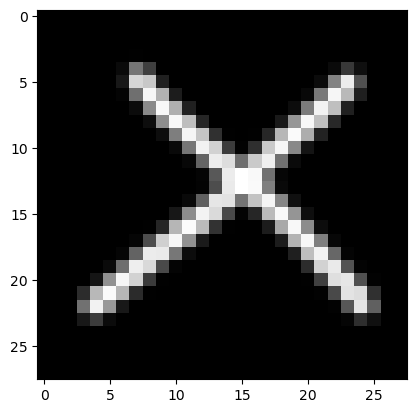

In [21]:
def Predict_Operator(image_path,Model:nn.Module,transform,device,show):
    Model.to(device)
    Model.eval()
    image = read_image(image_path)
    image = transform(image)
    image = image.unsqueeze(0)
    image = image.to(device)
    with torch.inference_mode():
        pred = Model(image)
        
    pred_prob = torch.softmax(pred,dim=1)
    pred_label = torch.argmax(pred_prob,dim=1)
    
    if show:
        plt.imshow(image.squeeze().cpu(),cmap='gray')
    
    return pred_label


op_path = r"C:\Users\abaan\OneDrive\Desktop\PROGRAMMING\DATA_SCIENCE\Deep_Learning\NIT_Project_DL\Test\mul_1.png"
operator = Predict_Operator(op_path,Operators_Model,custom_transform_op,device='cuda',show=True)

print(f'Predicted Operator : {class_names_op[operator]}')

class_names_op,operator

### Dictionary of Operators

In [22]:
class_names_op_dict = {'add':'+','div':'/','mul':'*','subtract':'-'}

### Function to Evaluate Expression

In [23]:
def Evaluate_Expression(digit_model,operator_model,first_digit,operator,second_digit,digit_transform,op_transform,device,show):

    if show:
        plt.subplot(1,3,1)
        num_1 = int(Predict_Digit(first_digit,digit_model,digit_transform,device=device,show=show))
        plt.subplot(1,3,2)
        op = Predict_Operator(operator,operator_model,op_transform,device=device,show=show)
        plt.subplot(1,3,3)
        num_2 = int(Predict_Digit(second_digit,digit_model,digit_transform,device=device,show=show))
    else:
        num_1 = int(Predict_Digit(first_digit,digit_model,digit_transform,device=device,show=show))
        op = Predict_Operator(operator,operator_model,op_transform,device=device,show=show)
        num_2 = int(Predict_Digit(second_digit,digit_model,digit_transform,device=device,show=show))

   
    op = class_names_op_dict[class_names_op[op]]
    result = eval(str(num_1) + op + str(num_2))

    print(f'{num_1} {op} {num_2} = {result}')

### Evaluation of Expression

7 + 3 = 10


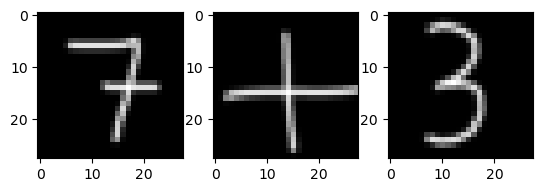

In [24]:
first = r"C:\Users\abaan\OneDrive\Desktop\PROGRAMMING\DATA_SCIENCE\Deep_Learning\NIT_Project_DL\Test\seven_1.png"
second = r"C:\Users\abaan\OneDrive\Desktop\PROGRAMMING\DATA_SCIENCE\Deep_Learning\NIT_Project_DL\Test\three_1.png"
oper = r"C:\Users\abaan\OneDrive\Desktop\PROGRAMMING\DATA_SCIENCE\Deep_Learning\NIT_Project_DL\Test\add_1.png"

show = True

Evaluate_Expression(digit_model=Digits_Model,operator_model=Operators_Model,first_digit=first,operator=oper,second_digit=second,digit_transform=digit_transform,op_transform=custom_transform_op,device='cuda',show=show)

In [25]:
# After training
torch.save(Digits_Model.state_dict(), 'digit_model.pth')
torch.save(Operators_Model.state_dict(), 'operator_model.pth')
